In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("IMG.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

**1. WAP to convert a grayscale image into a binary image.**

Case 1: Assume the mean intensity of the image as the threshold value.

Mean intensity = 71.7


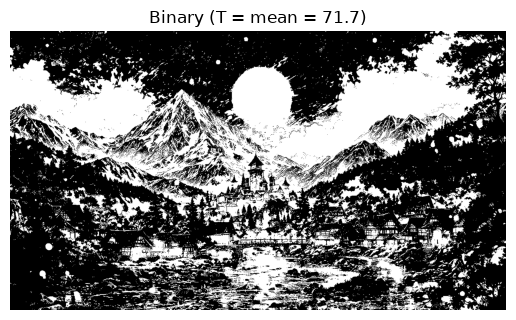

In [2]:
T1 = gray.mean()
print("Mean intensity =", round(T1, 2))

binary_mean = np.where(gray > T1, 255, 0).astype(np.uint8)

plt.imshow(binary_mean, cmap="gray")
plt.title("Binary (T = mean = " + str(round(T1, 2)) + ")")
plt.axis("off")
plt.show()

Case 2: Input the threshold value from the user.

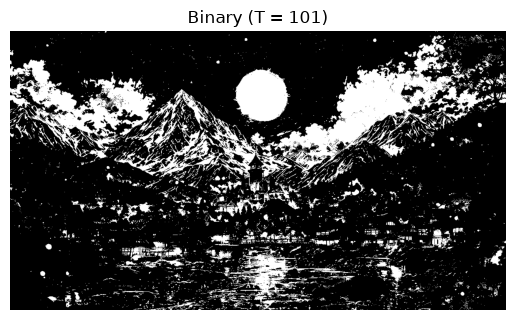

In [3]:
T2 = int(input("Enter the threshold value (0 - 255): "))

binary_user = np.where(gray > T2, 255, 0).astype(np.uint8)

plt.imshow(binary_user, cmap="gray")
plt.title("Binary (T = " + str(T2) + ")")
plt.axis("off")
plt.show()

**2. WAP to convert an RGB (color) image into a grayscale image.**

Case 1: Mean average of the three colour planes.

$$Gray = \frac{R + G + B}{3}$$

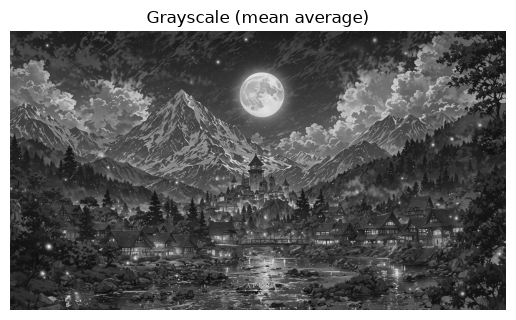

In [4]:
B, G, R = cv2.split(img)  

gray_mean = ((R.astype(float) + G.astype(float) + B.astype(float)) / 3).astype(np.uint8)

plt.imshow(gray_mean, cmap="gray")
plt.title("Grayscale (mean average)")
plt.axis("off")
plt.show()

Case 2: Input the weightages of R, G and B from the user (each between 0 and 1, summing to 1).

$$Gray = w_R R + w_G G + w_B B$$

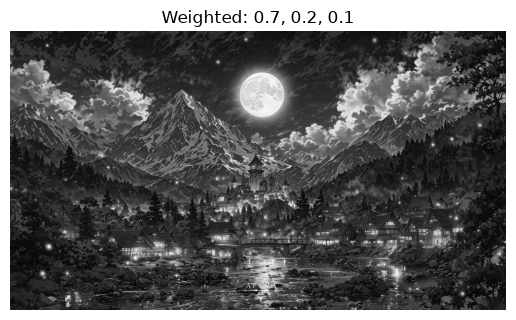

In [5]:
while True:
    wR = float(input("Weightage of R (0 - 1): "))
    wG = float(input("Weightage of G (0 - 1): "))
    wB = float(input("Weightage of B (0 - 1): "))

    if not (0 <= wR <= 1 and 0 <= wG <= 1 and 0 <= wB <= 1):
        print("Each weightage must lie between 0 and 1. Try again.\n")
    elif abs(wR + wG + wB - 1) > 1e-9:
        print("Weightages sum to", round(wR + wG + wB, 4), "instead of 1. Try again.\n")
    else:
        break

gray_weighted = (wR * R.astype(float) + wG * G.astype(float) + wB * B.astype(float)).astype(np.uint8)

plt.imshow(gray_weighted, cmap="gray")
plt.title("Weighted: " + str(wR) + ", " + str(wG) + ", " + str(wB))
plt.axis("off")
plt.show()